In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

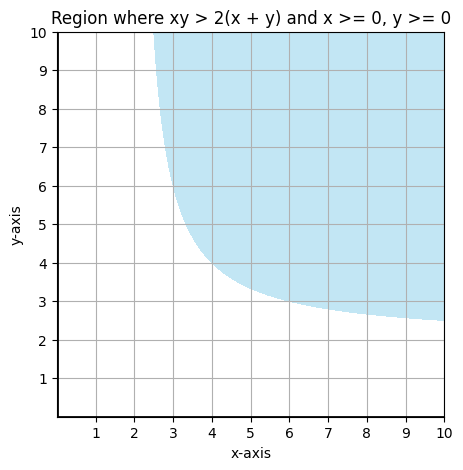

In [2]:
# define the range for x and y
x = np.linspace(0, 10, 400)
y = np.linspace(0, 10, 400)

# create a meshgrid for x and y
X, Y = np.meshgrid(x, y)

# define the inequality xy > 2(x + y)
inequality = X * Y - 2 * (X + Y)

# plot the region where the inequality is satisfied
plt.figure(figsize=(5, 5))
plt.contourf(X, Y, inequality, levels=[0, np.inf], colors='skyblue', alpha=0.5)

# add labels and title
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.title('Region where xy > 2(x + y) and x >= 0, y >= 0')

# set custom ticks for x-axis and y-axis
plt.xticks(np.arange(1, 11))
plt.yticks(np.arange(1, 11))

# show the plot
plt.grid(True)
plt.axhline(0, color='black', lw=2)
plt.axvline(0, color='black', lw=2)
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.show()

In [3]:
def get_cmap_colors(cmap_name, num_colors):
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(0, 1, num_colors))
    return colors

cmap_name = 'tab10'
num_colors = 10
# get a list of colors from the colormap
colors_list_10 = get_cmap_colors(cmap_name, num_colors)
# convert colors to a list of hex color codes
colors_hex_list_10 = ['#' + ''.join(f'{int(c * 255):02X}' for c in color[:3]) for color in colors_list_10]

In [4]:
def draw_and_save_validation(file_name, measure, output_png):
    # read file
    df = pd.read_csv(file_name)
    df['Precision'] = df['Precision'] / 100
    df['Recall'] = df['Recall'] / 100
    df['F1 Score'] = df['F1'] / 100
    # categorize data based on the ending of the 'Alignment' strings
    df['Category'] = df['Alignment'].apply(lambda x: 'Without VAL' if x.endswith('component/no_validation') 
                                           else ('With VAL' if x.endswith('component/') 
                                           else 'Unknown'))
    # set colors for each category
    colors = [colors_hex_list_10[0], colors_hex_list_10[1]]
    categories = ['Without VAL', 'With VAL']
    # calculate positions for each category to place them on the x-axis
    positions = np.arange(1, len(categories) + 1)
    # adjust jitter for better visibility
    jitter = 0.15
    np.random.seed(42)
    # marker size
    marker_size = 50
    # calculate the maximum size of any category
    max_size = df['Category'].value_counts().max()
    # generate jitter values based on the maximum size
    jitter_values = np.random.normal(0, jitter, size=max_size)
    
    # figure size
    fig, ax = plt.subplots(figsize=(2.5, 3))
    # plotting each category with jitter
    for pos, category, color in zip(positions, categories, colors):
        # extract the precision values for the current category
        precision_values = df[measure][df['Category'] == category].values
        # apply jitter: randomly adjust the x position slightly to reduce overlap
        current_size = len(precision_values)
        jittered_x = pos + jitter_values[:current_size]
        # jittered_x = pos + np.random.normal(0, jitter, size=len(precision_values))
        ax.scatter(jittered_x, precision_values, color=color, alpha=0.7, label=category, s=marker_size)
        
    # customizing the plot
    ax.set_title(measure)
    # ax.set_xlabel('Category')
    # ax.set_ylabel(measure)
    ax.set_xticks(positions)
    ax.set_xticklabels(categories)
    ax.set_xlim(0.5, len(categories) + 0.5)
    ax.set_ylim([-0.05, 1.05])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    # ax.legend()
    
    plt.savefig(output_png, bbox_inches='tight', pad_inches=0.1)
    
    plt.show()

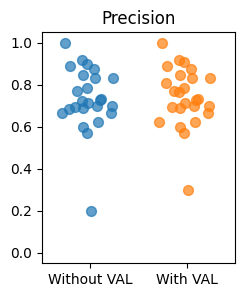

In [5]:
draw_and_save_validation("result-reference.csv", "Precision", "result_figure/validation-precision.png")

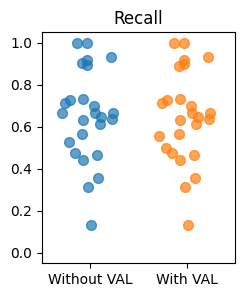

In [6]:
draw_and_save_validation("result-reference.csv", "Recall", "result_figure/validation-recall.png")

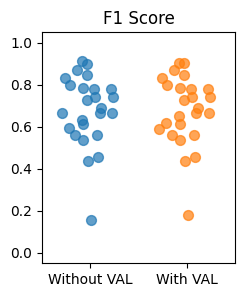

In [7]:
draw_and_save_validation("result-reference.csv", "F1 Score", "result_figure/validation-f1.png")

In [8]:
def draw_and_save_merge(file_name, measure, output_png):
    # read file
    df = pd.read_csv(file_name)
    df['Precision'] = df['Precision'] / 100
    df['Recall'] = df['Recall'] / 100
    df['F1 Score'] = df['F1'] / 100
    # categorise data based on the ending of the 'Alignment' strings
    df['Category'] = df['Alignment'].apply(lambda x: '$O_s \Rightarrow O_t$' if x.endswith('source') 
                                           else ('$O_s \Leftarrow O_t$' if x.endswith('target') 
                                           else ('$O_s \Leftrightarrow O_t$' if x.endswith('/') 
                                           else 'Unknown')))
    
    # set colors for each category
    colors = [colors_hex_list_10[0], colors_hex_list_10[1], colors_hex_list_10[2]]
    categories = ['$O_s \Rightarrow O_t$', '$O_s \Leftarrow O_t$', '$O_s \Leftrightarrow O_t$']
    # calculate positions for each category to place them on the x-axis
    positions = np.arange(1, len(categories) + 1)
    # adjust jitter for better visibility
    jitter = 0.15
    np.random.seed(42)
    # set marker size
    marker_size = 50
    # calculate the maximum size of any category
    max_size = df['Category'].value_counts().max()
    # generate jitter values based on the maximum size
    jitter_values = np.random.normal(0, jitter, size=max_size)
    
    # set figure size
    fig, ax = plt.subplots(figsize=(2.5, 3))
    # plot each category with jitter
    for pos, category, color in zip(positions, categories, colors):
        # extract the precision values for the current category
        precision_values = df[measure][df['Category'] == category].values
        # apply jitter: randomly adjust the x position slightly to reduce overlap
        current_size = len(precision_values)
        jittered_x = pos + jitter_values[:current_size]
        # jittered_x = pos + np.random.normal(0, jitter, size=len(precision_values))
        ax.scatter(jittered_x, precision_values, color=color, alpha=0.7, label=category, s=marker_size)
        
    # customise the plot
    ax.set_title(measure)
    # ax.set_xlabel('Category')
    # ax.set_ylabel(measure)
    ax.set_xticks(positions)
    ax.set_xticklabels(categories)
    ax.set_xlim(0.5, len(categories) + 0.5)
    ax.set_ylim([-0.05, 1.05])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    # ax.legend()
    
    plt.savefig(output_png, bbox_inches='tight', pad_inches=0.1)
    
    plt.show()

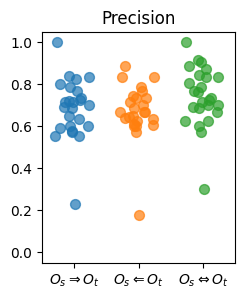

In [9]:
draw_and_save_merge("result-reference.csv", "Precision", "result_figure/merge-precision.png")

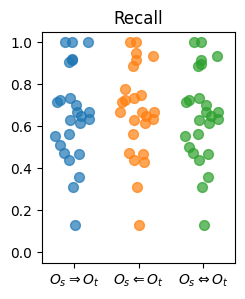

In [10]:
draw_and_save_merge("result-reference.csv", "Recall", "result_figure/merge-recall.png")

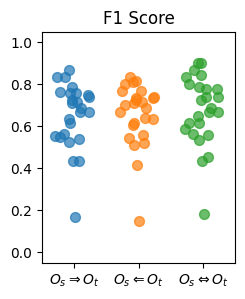

In [11]:
draw_and_save_merge("result-reference.csv", "F1 Score", "result_figure/merge-f1.png")

In [12]:
df = pd.read_csv("result-similarity-cmt-conference.csv")
# filter rows where the "Alignment" column ends with a number
df = df[df['Alignment'].str.match(r'.*-$')]
# extract decimal numbers from 0.1 to 1.0 in the "Alignment" column
df['Alignment'] = df['Alignment'].str.extract('(0\.[1-9][0-9]?|1\.0)')
# convert the "Alignment" column to numeric
df['Alignment'] = pd.to_numeric(df['Alignment'], errors='coerce')
# sort the DataFrame by the "Alignment" column in descending order, if needed
df = df.sort_values(by='Alignment', ascending=False)
# set values [0,1]
df['Precision'] = df['Precision'] / 100
df['Recall'] = df['Recall'] / 100
df.rename(columns={'F1': 'F1 Score'}, inplace=True)
df['F1 Score'] = df['F1 Score'] / 100
# set 'Alignment' as the index
df.set_index('Alignment', inplace=True)
df

,Precision,Recall,F1 Score
Alignment,,,
1.00,0.5000,0.1333,0.2105
0.95,0.6364,0.4667,0.5385
0.90,0.3750,0.6000,0.4615
0.85,0.3333,0.7333,0.4583
0.80,0.3704,0.6667,0.4762
0.75,0.3793,0.7333,0.5000
0.70,0.3448,0.6667,0.4545
0.65,0.3667,0.7333,0.4889
0.60,0.3929,0.7333,0.5116


In [13]:
def draw_and_save_similarity(output_png):

    df[['Precision', 'Recall', 'F1 Score']].plot(kind='line', marker='o', figsize=(6, 1.5),color=colors_hex_list_10)
    # plt.figure(figsize=(10, 2))
    # plt.plot(df['Alignment'], df[measure], marker='o', linestyle='-', linewidth=2, color=colors_hex_list_10[color_order])

    # set x-axis label
    plt.xlabel('Similarity Threshold')
    # set y-axis label
    # plt.ylabel(measure)
    # show grid lines
    # plt.grid(True)

    # invert the x-axis to have 1.0 on the left and 0.1 on the right
    plt.gca().invert_xaxis()

    # set x-axis range
    plt.xticks(np.arange(1.0, 0.45, -0.05))
    # set y-axis range
    plt.yticks(np.arange(0.0, 1.1, 0.2))
    # set legend
    plt.legend(loc='upper left', bbox_to_anchor=(-0.35, 0.8), frameon=False)
    # save the figure
    plt.savefig(output_png, bbox_inches='tight', pad_inches=0.1)
    # plot the figure
    plt.show()

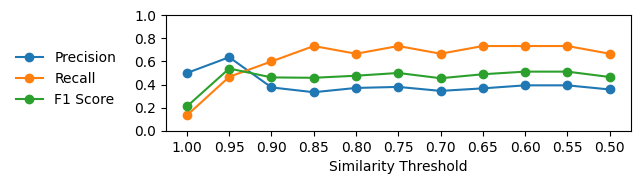

In [14]:
draw_and_save_similarity("result_figure/similarity.png")